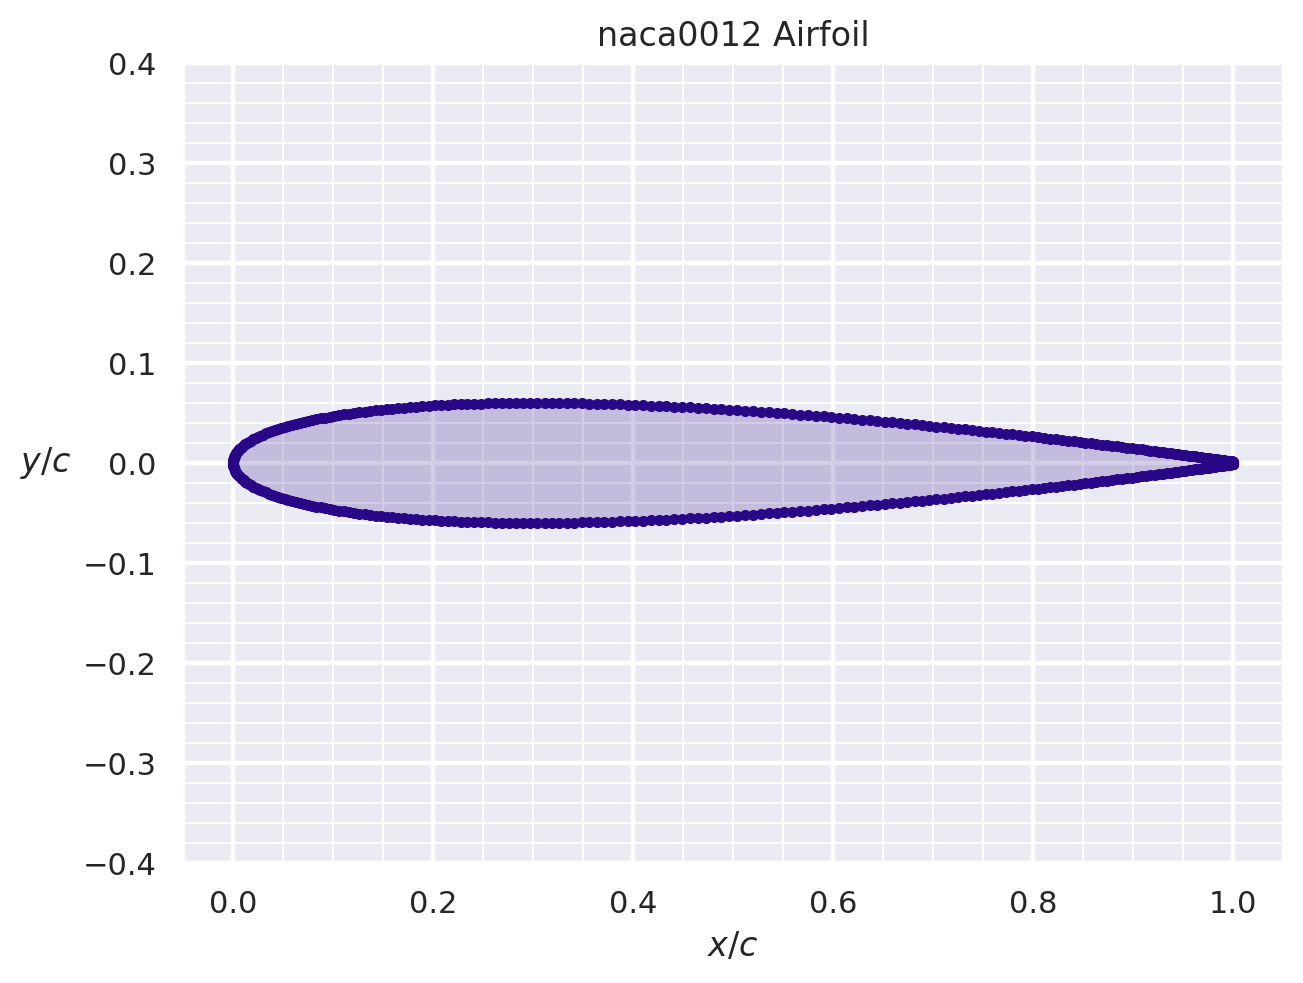

/home/vimarsh/miniconda3/envs/aerialgym/lib/python3.8/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


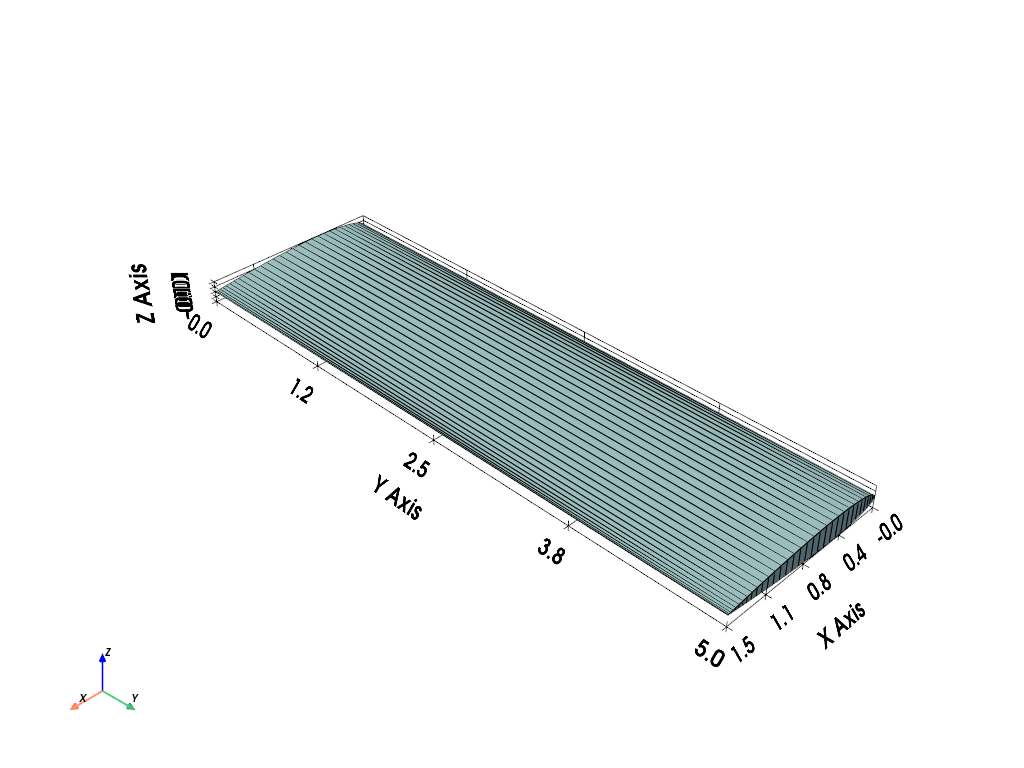

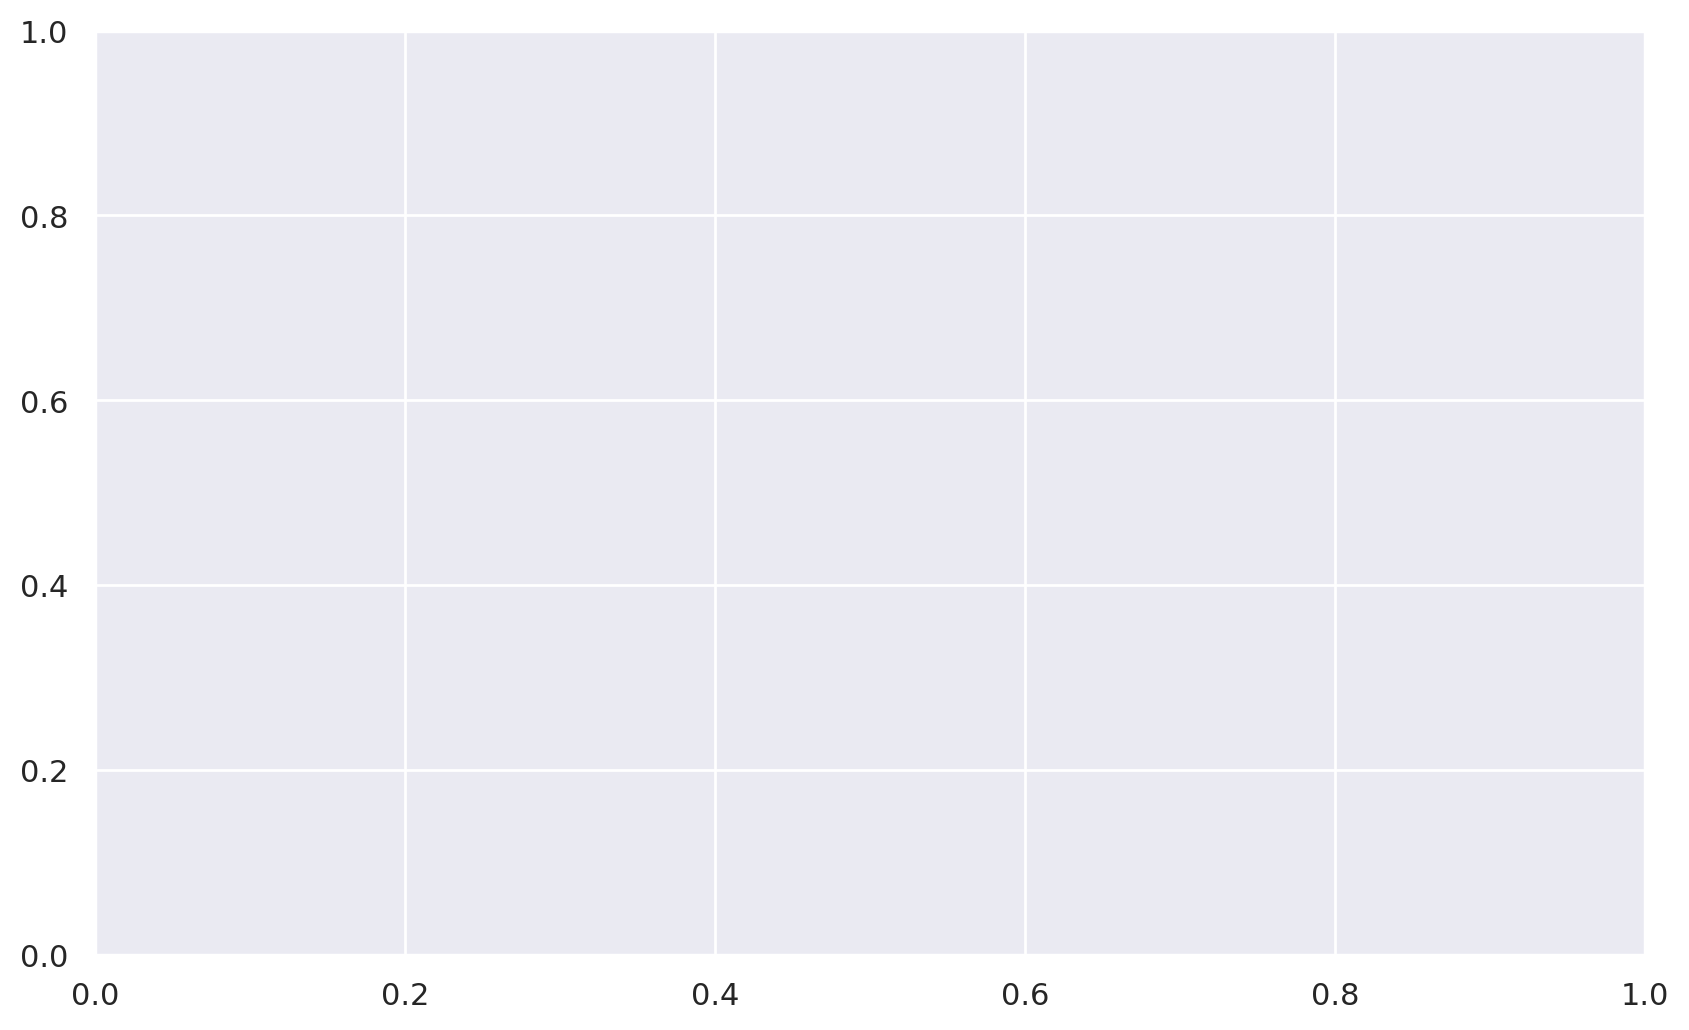

Forces in geometry axes: [array([ -0.89092899,  -4.08602696,  -9.65359323, -17.63534452,
       -28.06139295]), array([0., 0., 0., 0., 0.]), array([ 37.11487419, 142.96399806, 323.07101117, 578.87002225,
       911.0413331 ])]
Forces in body axes: (array([ 0.89092899,  4.08602696,  9.65359323, 17.63534452, 28.06139295]), array([0., 0., 0., 0., 0.]), array([ -37.11487419, -142.96399806, -323.07101117, -578.87002225,
       -911.0413331 ]))
Forces in wind axes: (array([ -2.34723569,  -8.38965504, -18.54063555, -32.88361003,
       -51.44787319]), array([0., 0., 0., 0., 0.]), array([ -37.05129047, -142.7760976 , -322.68299452, -578.2042686 ,
       -910.02025732]))


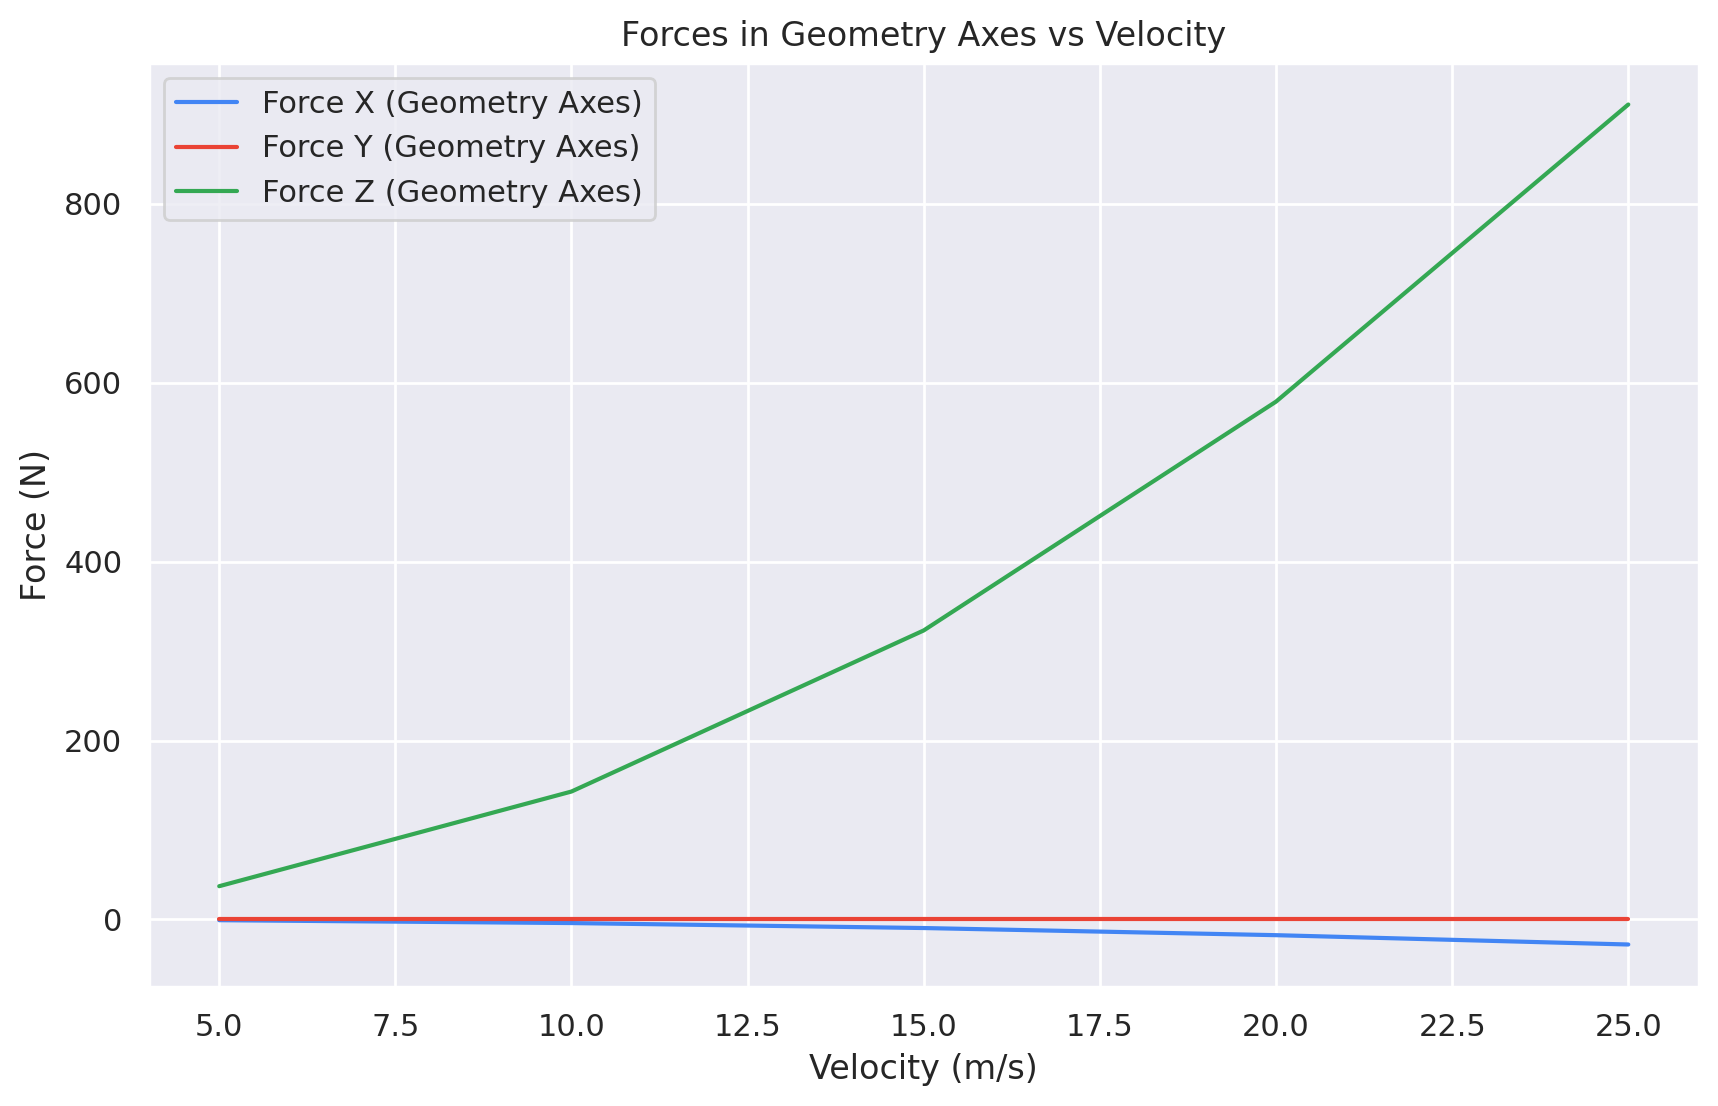

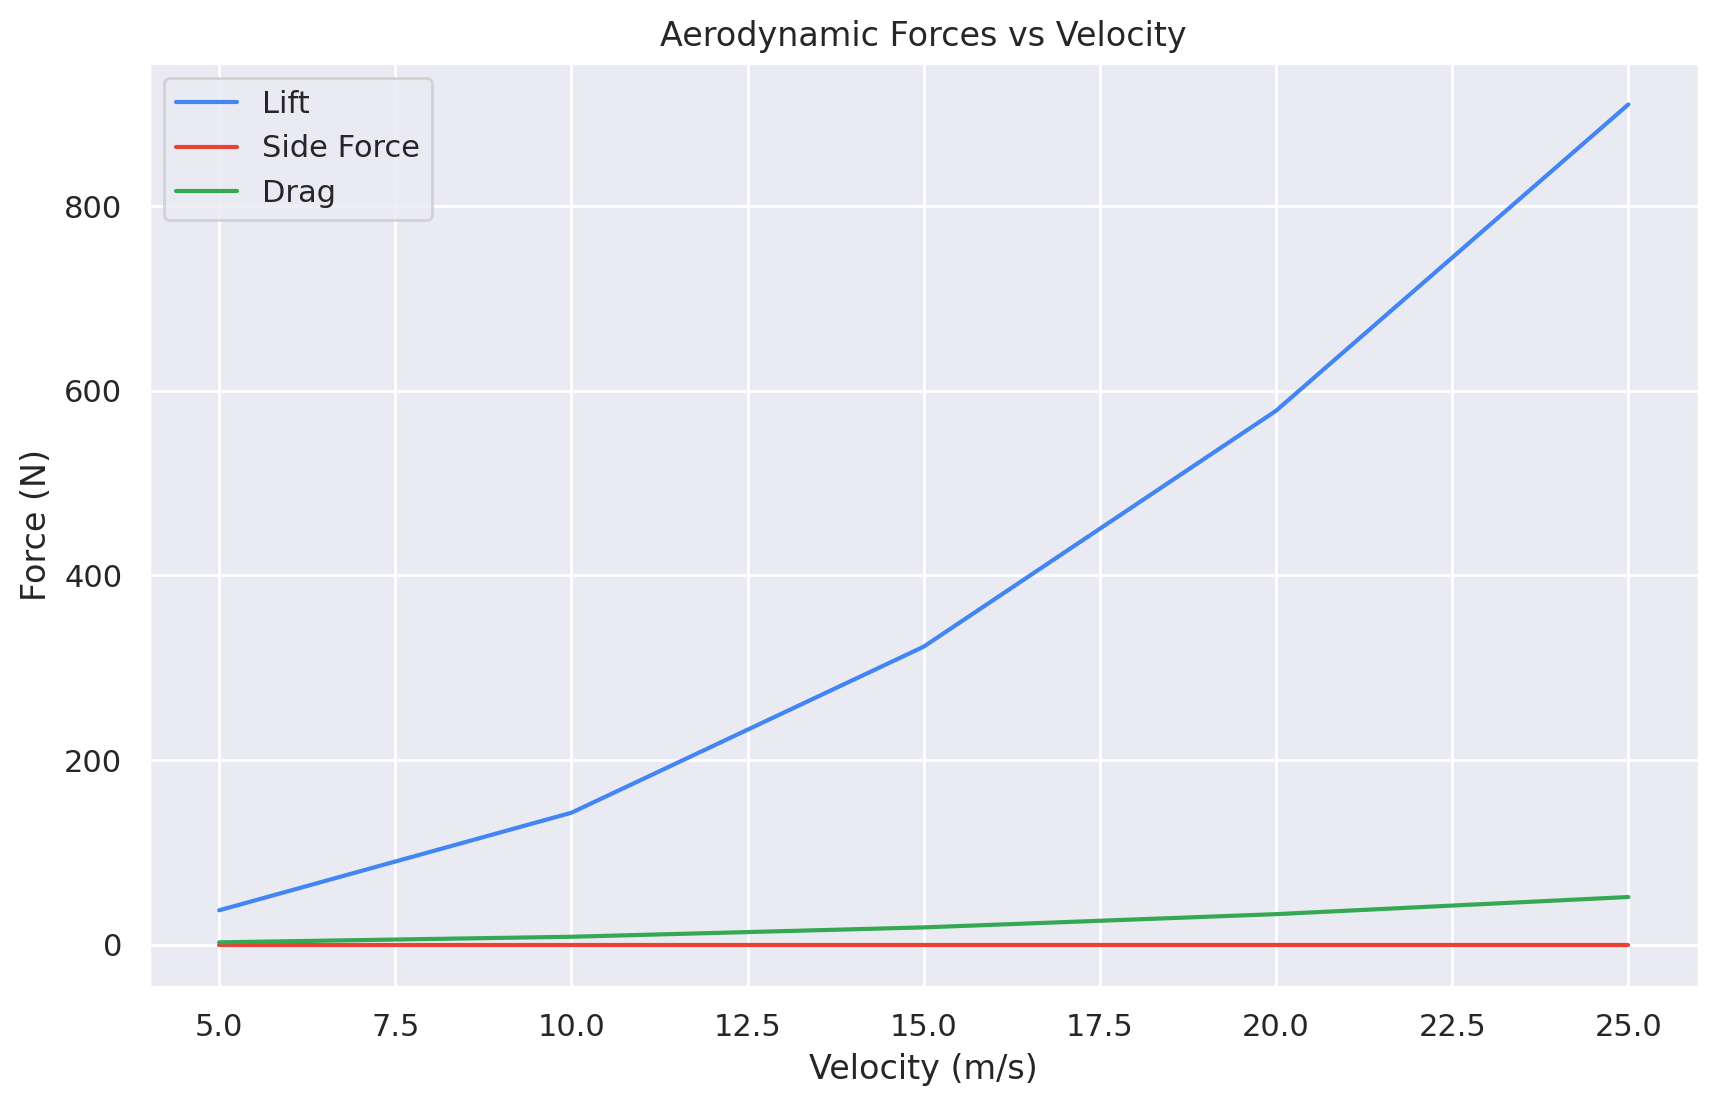

Lift: [ 37.05129047 142.7760976  322.68299452 578.2042686  910.02025732]
Side Force: [0. 0. 0. 0. 0.]
Drag: [ 2.34723569  8.38965504 18.54063555 32.88361003 51.44787319]


In [3]:
import aerosandbox as asb
import numpy as np
import matplotlib.pyplot as plt

af = asb.Airfoil("naca0012")
af.draw()

velocity = np.linspace(5, 25, 5)
aero_analysis = asb.AeroBuildup(
    airplane = asb.Airplane(
        wings=[
            asb.Wing(
                name="Main Wing",
                xsecs=[
                    asb.WingXSec(
                        xyz_le=[0, 0, 0],
                        chord=1.5,
                        airfoil=af
                    ),
                    asb.WingXSec(
                        xyz_le=[0, 5, 0],
                        chord=1.5,
                        airfoil=af
                    )
                ]
            )
        ]
    ),
    op_point = asb.OperatingPoint(
        velocity=velocity,
        alpha=5,
        beta=0,
        p=0,
        q=0,
        r=0,
    )

)

fig, ax = plt.subplots(figsize=(10, 6))
aero_analysis.airplane.draw()
aero_analysis
plt.show()

results = aero_analysis.run()

forces_geometry = results["F_g"]
forces_body = results["F_b"]
forces_wind = results["F_w"]

print("Forces in geometry axes:", forces_geometry)
print("Forces in body axes:", forces_body)
print("Forces in wind axes:", forces_wind)

plt.figure(figsize=(10, 6))
plt.plot(aero_analysis.op_point.velocity, forces_geometry[0], label="Force X (Geometry Axes)")
plt.plot(aero_analysis.op_point.velocity, forces_geometry[1], label="Force Y (Geometry Axes)")
plt.plot(aero_analysis.op_point.velocity, forces_geometry[2], label="Force Z (Geometry Axes)")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Force (N)")
plt.title("Forces in Geometry Axes vs Velocity")
plt.legend()
plt.grid(True)
plt.show()


lift = results["L"]
side_force = results["Y"]
drag = results["D"]

plt.figure(figsize=(10, 6))
plt.plot(aero_analysis.op_point.velocity, lift, label="Lift")
plt.plot(aero_analysis.op_point.velocity, side_force, label="Side Force")
plt.plot(aero_analysis.op_point.velocity, drag, label="Drag")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Force (N)")
plt.title("Aerodynamic Forces vs Velocity")
plt.legend()
plt.grid(True)
plt.show()

print("Lift:", lift)
print("Side Force:", side_force)
print("Drag:", drag)


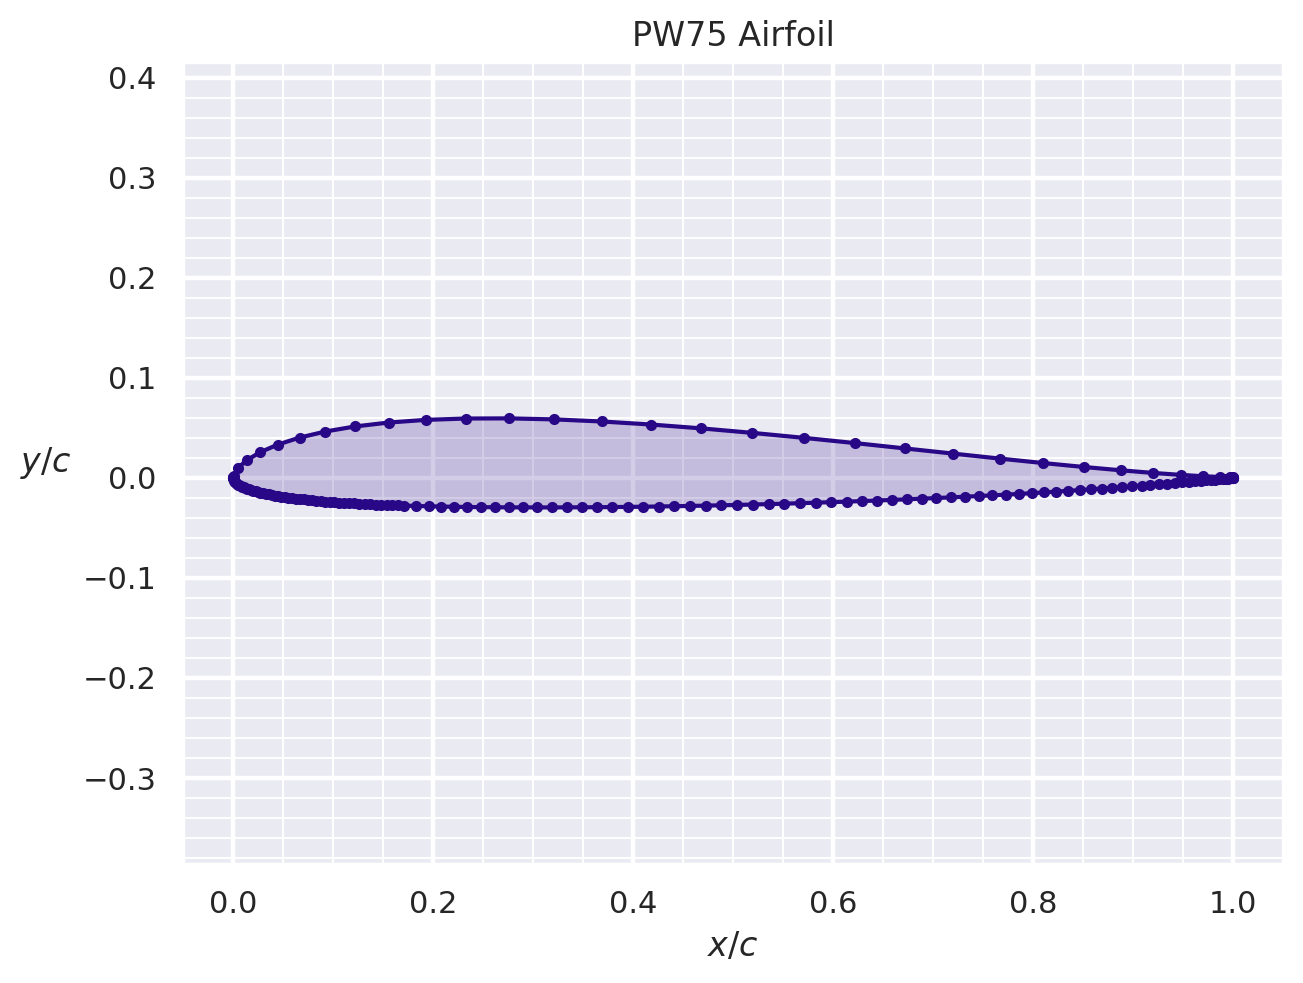

/home/vimarsh/miniconda3/envs/aerialgym/lib/python3.8/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


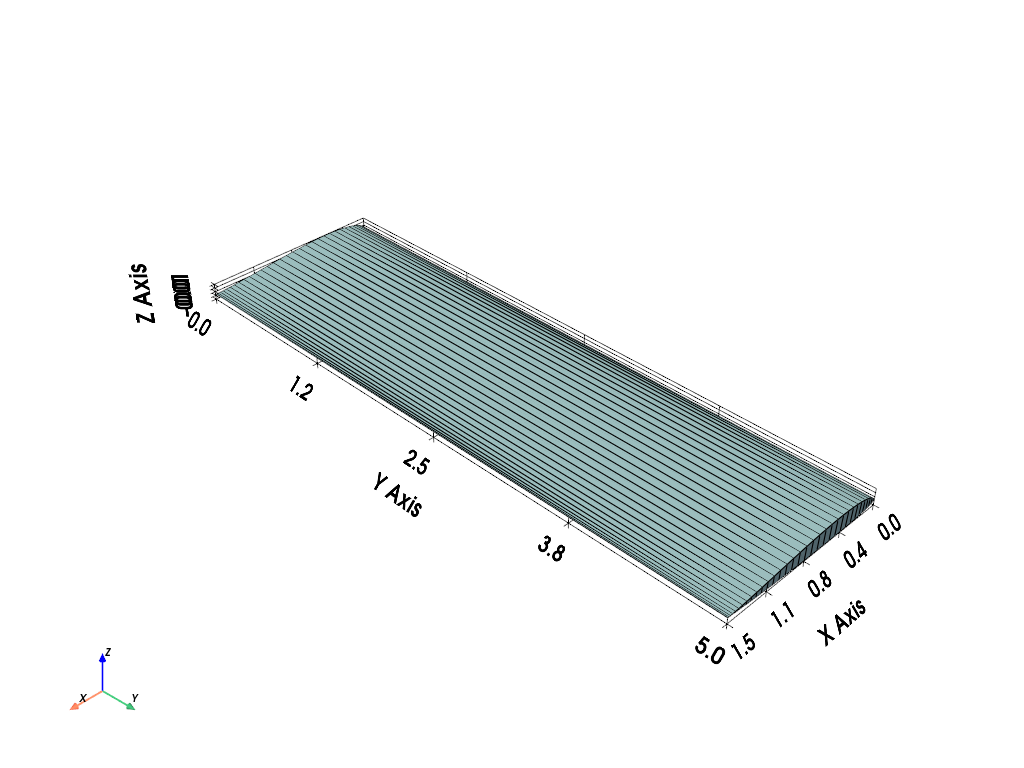

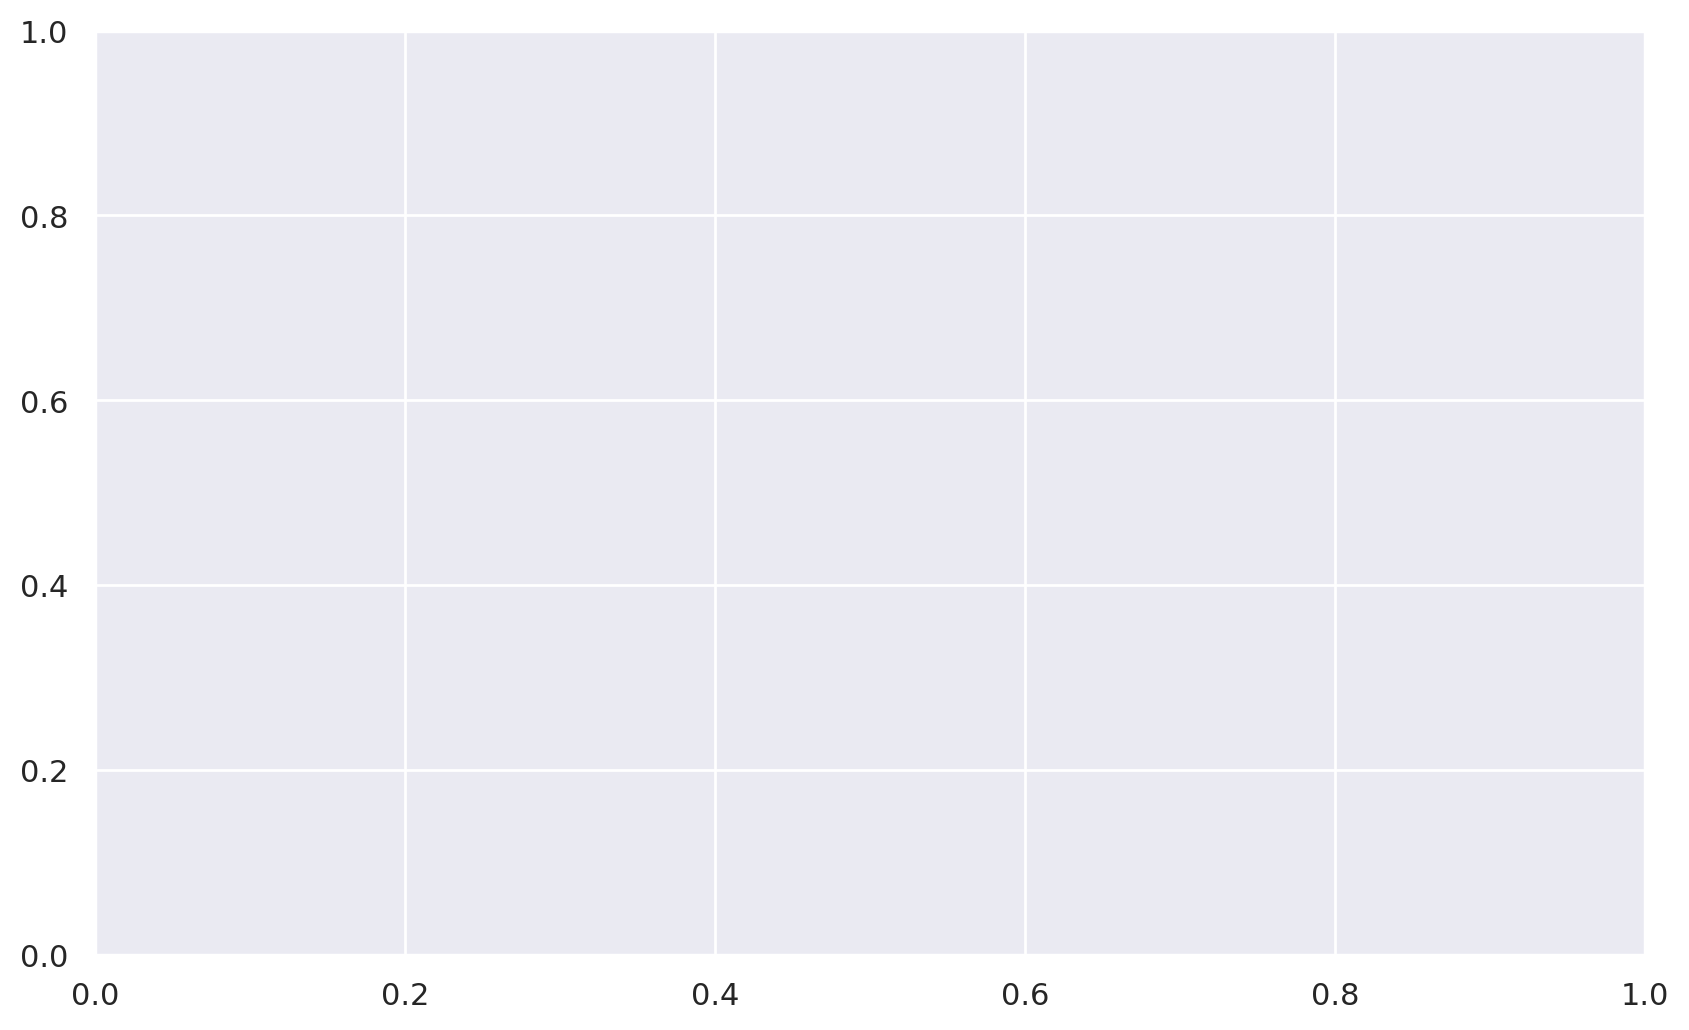

Forces in geometry axes: [array([ -0.95161636,  -2.20711335,  -4.00191344,  -6.33892635,
        -9.21993394, -12.64588334, -16.61734362, -21.13484623,
       -26.19904876, -31.81075876]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([  45.98018192,   93.81694149,  157.20835811,  235.74057136,
        329.17989812,  437.43666537,  560.53922712,  698.60897347,
        851.83586231, 1020.45568779])]
Forces in body axes: (array([ 0.95161636,  2.20711335,  4.00191344,  6.33892635,  9.21993394,
       12.64588334, 16.61734362, 21.13484623, 26.19904876, 31.81075876]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([  -45.98018192,   -93.81694149,  -157.20835811,  -235.74057136,
        -329.17989812,  -437.43666537,  -560.53922712,  -698.60897347,
        -851.83586231, -1020.45568779]))
Forces in wind axes: (array([ -3.05944173,  -5.9779706 ,  -9.71492627, -14.23133977,
       -19.50506921, -25.52735554, -32.30010307, -39.83336221,
       -48.14303381, -57.24886419]), arra

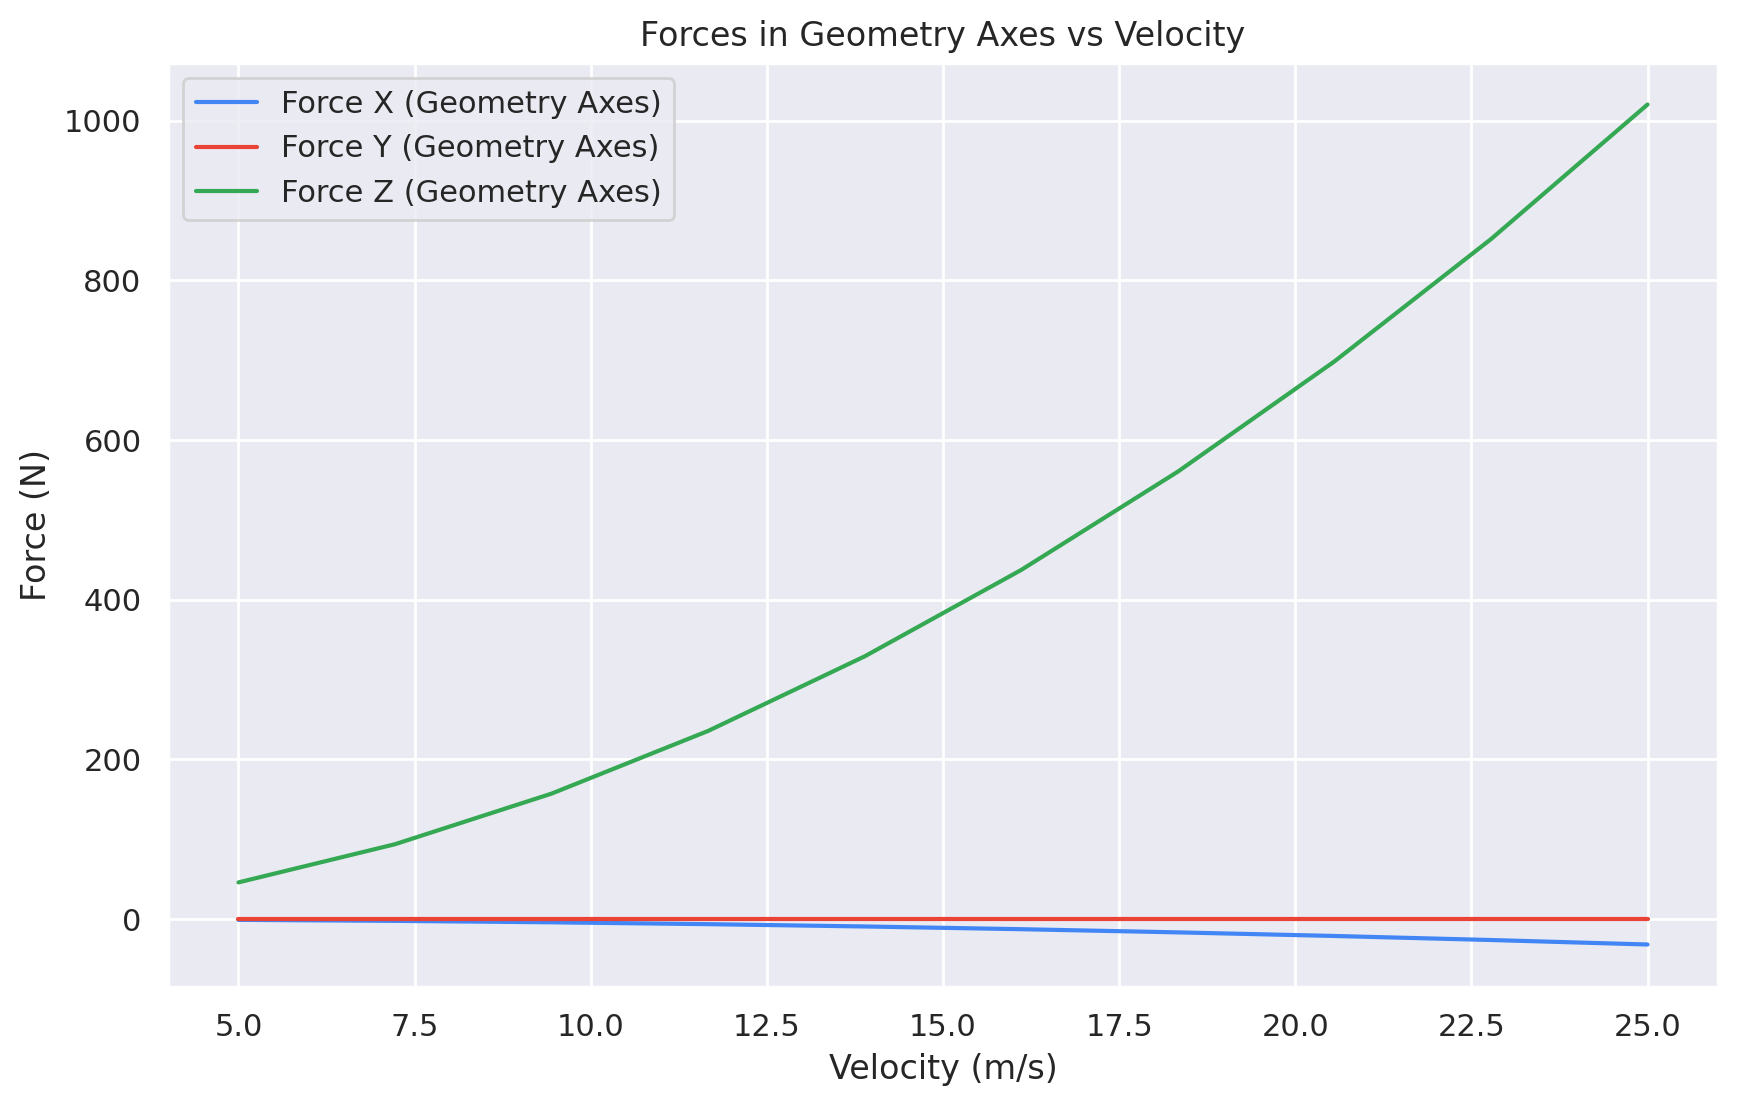

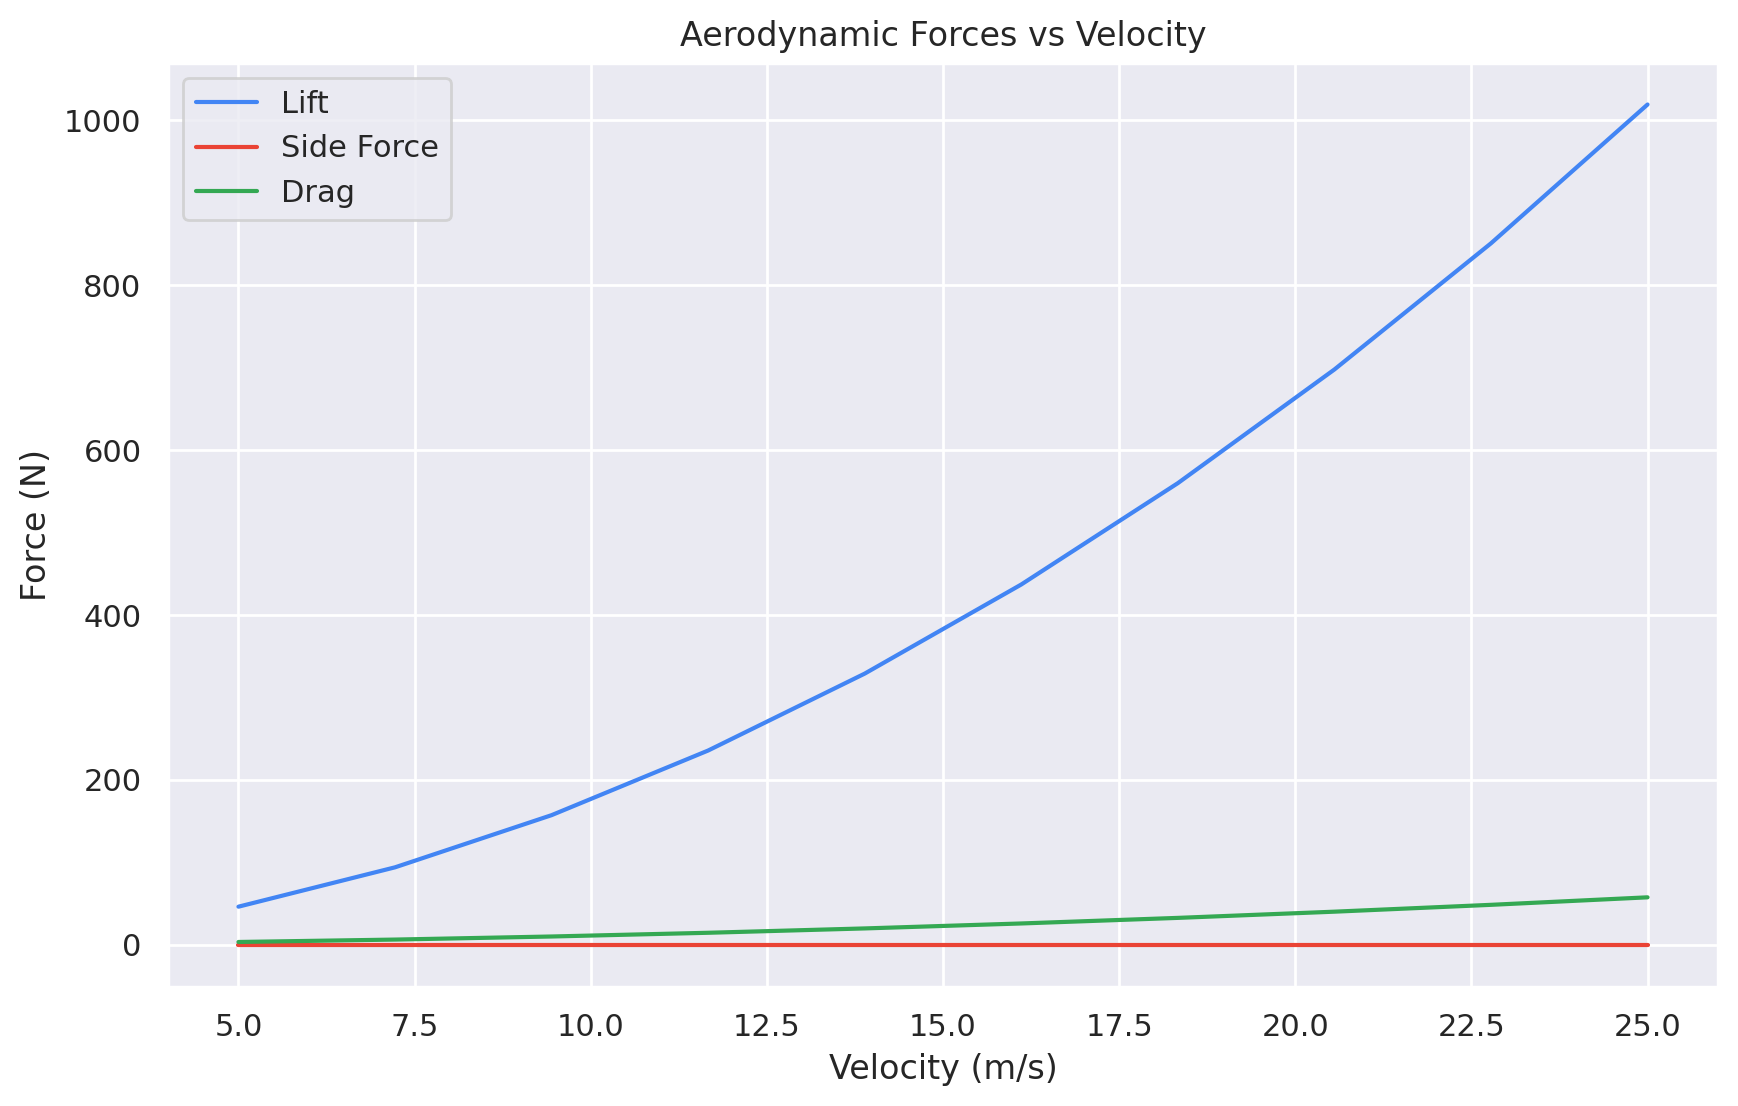

Lift: [  45.88815228   93.6523023   156.95892258  235.39598114  328.73083942
  436.87424815  559.85450306  697.79257864  850.87776723 1019.34503612]
Side Force: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Drag: [ 3.05944173  5.9779706   9.71492627 14.23133977 19.50506921 25.52735554
 32.30010307 39.83336221 48.14303381 57.24886419]


In [2]:
import aerosandbox as asb
import numpy as np
import matplotlib.pyplot as plt

af = asb.Airfoil("PW75")
af.draw()

velocity = np.linspace(5, 25, 10)
aero_analysis = asb.AeroBuildup(
    airplane = asb.Airplane(
        wings=[
            asb.Wing(
                name="Main Wing",
                xsecs=[
                    asb.WingXSec(
                        xyz_le=[0, 0, 0],
                        chord=1.5,
                        airfoil=af
                    ),
                    asb.WingXSec(
                        xyz_le=[0, 5, 0],
                        chord=1.5,
                        airfoil=af
                    )
                ]
            )
        ]
    ),
    op_point = asb.OperatingPoint(
        velocity=velocity,
        alpha=5,
        beta=0,
        p=0,
        q=0,
        r=0,
    )

)

fig, ax = plt.subplots(figsize=(10, 6))
aero_analysis.airplane.draw()
aero_analysis
plt.show()

results = aero_analysis.run()

forces_geometry = results["F_g"]
forces_body = results["F_b"]
forces_wind = results["F_w"]

print("Forces in geometry axes:", forces_geometry)
print("Forces in body axes:", forces_body)
print("Forces in wind axes:", forces_wind)

plt.figure(figsize=(10, 6))
plt.plot(aero_analysis.op_point.velocity, forces_geometry[0], label="Force X (Geometry Axes)")
plt.plot(aero_analysis.op_point.velocity, forces_geometry[1], label="Force Y (Geometry Axes)")
plt.plot(aero_analysis.op_point.velocity, forces_geometry[2], label="Force Z (Geometry Axes)")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Force (N)")
plt.title("Forces in Geometry Axes vs Velocity")
plt.legend()
plt.grid(True)
plt.show()


lift = results["L"]
side_force = results["Y"]
drag = results["D"]

plt.figure(figsize=(10, 6))
plt.plot(aero_analysis.op_point.velocity, lift, label="Lift")
plt.plot(aero_analysis.op_point.velocity, side_force, label="Side Force")
plt.plot(aero_analysis.op_point.velocity, drag, label="Drag")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Force (N)")
plt.title("Aerodynamic Forces vs Velocity")
plt.legend()
plt.grid(True)
plt.show()

print("Lift:", lift)
print("Side Force:", side_force)
print("Drag:", drag)
